<h1><b><span style="color: #e74c3c;"> Text Representation and Embedding Techniques</span>  </h1></b>



<b><h3><span style="color: #3498db;">Text Representation Techniques</b></span> </h3> 
<b><span style="color: #2ecc71;">One Hot Encoding in Machine Learning</b></span>  

- <span style="color: #9b59b6;">Purple item</span>
- <span style="color: #e67e22;">Orange item</span>
- <span style="color: #f1c40f;">Yellow item</span>
"""


In [1]:
#  1. Using Pandas

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)
print(f"Original Employee Data:\n{df}\n")
# Use pd.get_dummies() to one-hot encode the categorical columns
df_pandas_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'], drop_first=True)
print(f"One-Hot Encoded Data using Pandas:\n{df_pandas_encoded}\n")

encoder = OneHotEncoder(sparse_output=False)


Original Employee Data:
   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice

One-Hot Encoded Data using Pandas:
   Employee id  Gender_M  Remarks_Great  Remarks_Nice
0           10      True          False         False
1           20     False          False          True
2           15     False          False         False
3           25      True           True         False
4           30     False          False          True



In [2]:
# 2. Using Scikit Learn Library
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {'Employee id': [10, 20, 15, 25, 30],
        'Gender': ['M', 'F', 'F', 'M', 'F'],
        'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice'],
        }
df = pd.DataFrame(data)
print(f"Employee data : \n{df}")

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded Employee data : \n{df_encoded}")

Employee data : 
   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice
Encoded Employee data : 
   Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10       0.0       1.0           1.0            0.0           0.0
1           20       1.0       0.0           0.0            0.0           1.0
2           15       1.0       0.0           1.0            0.0           0.0
3           25       0.0       1.0           0.0            1.0           0.0
4           30       1.0       0.0           0.0            0.0           1.0


C:\Users\T14\AppData\Local\Temp\ipykernel_11452\3741047785.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


<b><h3><span style="color: #3498db;">Bag of words (BoW) model in NLP</b></span> </h3> 
<b><span style="color: #2ecc71;">Step 1: Preprocessing the Text</b></span>  


In [3]:
import nltk
nltk.download('punkt_tab') 
nltk.download('punkt_t') 


import re
import pandas as pd
from nltk.corpus import stopwords

text = """Beans. I was trying to explain to somebody as we were flying in, that's corn.
         That's beans. And they were very impressed at my agricultural knowledge. 
         Please give it up for Amaury once again for that outstanding introduction. 
         I have a bunch of good friends here today, including somebody who I served with, 
         who is one of the finest senators in the country, and we're lucky to have him, 
         your Senator, Dick Durbin is here. I also noticed, by the way, 
         former Governor Edgar here, who I haven't seen in a long time, and 
         somehow he has not aged and I have. And it's great to see you, Governor. 
         I want to thank President Killeen and everybody at the U of I System for 
         making it possible for me to be here today. And I am deeply honored at the Paul 
         Douglas Award that is being given to me. He is somebody who set the path for so 
         much outstanding public service here in Illinois. Now, I want to start by 
         addressing the elephant in the room. I know people are still wondering why 
         I didn't speak at the commencement."""

dataset = nltk.sent_tokenize(text)

for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

for i, sentence in enumerate(dataset):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: beans 
Sentence 2: i was trying to explain to somebody as we were flying in that s corn 
Sentence 3: that s beans 
Sentence 4: and they were very impressed at my agricultural knowledge 
Sentence 5: please give it up for amaury once again for that outstanding introduction 
Sentence 6: i have a bunch of good friends here today including somebody who i served with who is one of the finest senators in the country and we re lucky to have him your senator dick durbin is here 
Sentence 7: i also noticed by the way former governor edgar here who i haven t seen in a long time and somehow he has not aged and i have 
Sentence 8: and it s great to see you governor 
Sentence 9: i want to thank president killeen and everybody at the u of i system for making it possible for me to be here today 
Sentence 10: and i am deeply honored at the paul douglas award that is being given to me 
Sentence 11: he is somebody who set the path for so much outstanding public service here in illinois 
Sente

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\T14\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Error loading punkt_t: Package 'punkt_t' not found in
[nltk_data]     index


<b><span style="color: #2ecc71;">Step 2: Counting Word Frequencies</b></span>  



In [4]:

nltk.download('stopwords')
word2count = {}

for data in dataset:
    words = nltk.word_tokenize(data)
    for word in words:
        if word not in word2count:
            word2count[word] = 1
        else:
            word2count[word] += 1

stop_words = set(stopwords.words('english'))

filtered_word2count = {word: count for word, count in word2count.items() if word not in stop_words}

word_freq_df = pd.DataFrame(list(filtered_word2count.items()), columns=['Word', 'Frequency'])

word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

print(word_freq_df)

            Word  Frequency
3       somebody          3
0          beans          2
12   outstanding          2
41          want          2
17         today          2
..           ...        ...
31        former          1
33         edgar          1
34          seen          1
35          long          1
71  commencement          1

[72 rows x 2 columns]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\T14\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<b><span style="color: #2ecc71;">Step 3: Selecting the Most Frequent Words</b></span>  


Top 10 frequent words: ['i', 'the', 'to', 'and', 'in', 'for', 'here', 'that', 'at', 'who']


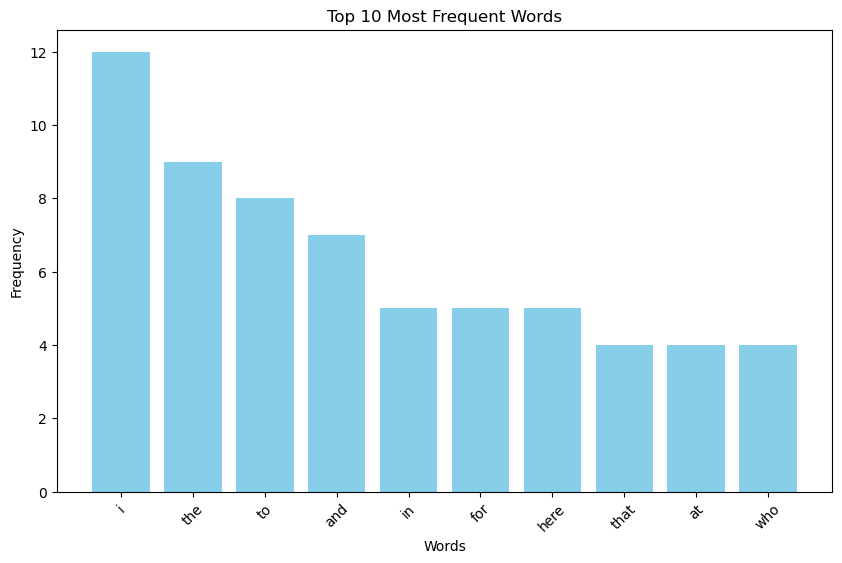

In [5]:
import heapq
import matplotlib.pyplot as plt

freq_words = heapq.nlargest(10, word2count, key=word2count.get)

print(f"Top 10 frequent words: {freq_words}")

top_words = sorted(word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

<b><span style="color: #2ecc71;">Step 4: Building the Bag of Words (BoW) Model</b></span>  


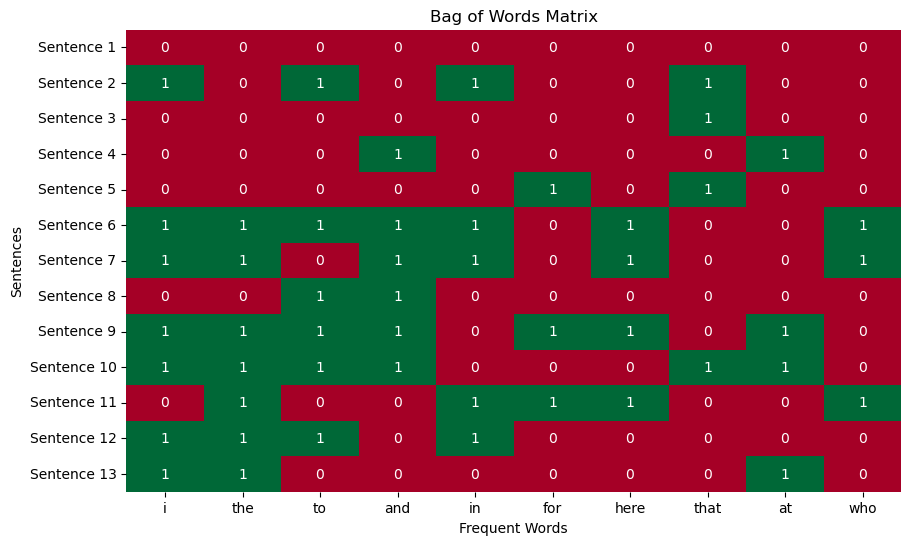

In [6]:
import numpy as np
import seaborn as sns

X = []

for data in dataset:
    vector = []
    for word in freq_words:
        if word in nltk.word_tokenize(data):
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

plt.figure(figsize=(10, 6))
sns.heatmap(X, cmap='RdYlGn', cbar=False, annot=True, fmt="d", xticklabels=freq_words, yticklabels=[f"Sentence {i+1}" for i in range(len(dataset))])

plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

<b><span style="color: #2ecc71;">Step 5: Visualizing Word Frequencies with a Word Cloud
</b></span>  


Note: you may need to restart the kernel to use updated packages.


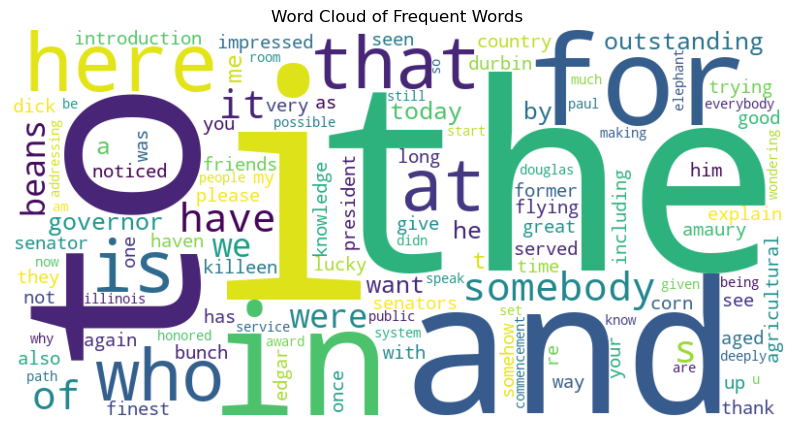

In [7]:
%pip install wordcloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word2count)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequent Words")
plt.show()

<b><h3><span style="color: #3498db;">Term Frequency-Inverse Document Frequency</b></span> </h3> 

<b><span style="color: #2ecc71;">Implementing TF-IDF
</b></span>  


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
d0 = 'Geeks for geeks'
d1 = 'Geeks'
d2 = 'r2j'
string = [d0, d1, d2]

In [10]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(string)

In [11]:
print('\nidf values:')
for ele1, ele2 in zip(tfidf.get_feature_names_out(), tfidf.idf_):
    print(ele1, ':', ele2)


idf values:
for : 1.6931471805599454
geeks : 1.2876820724517808
r2j : 1.6931471805599454


In [12]:
print('\nWord indexes:')
print(tfidf.vocabulary_)
print('\ntf-idf value:')
print(result)
print('\ntf-idf values in matrix form:')
print(result.toarray())


Word indexes:
{'geeks': 1, 'for': 0, 'r2j': 2}

tf-idf value:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (3, 3)>
  Coords	Values
  (0, 1)	0.8355915419449176
  (0, 0)	0.5493512310263033
  (1, 1)	1.0
  (2, 2)	1.0

tf-idf values in matrix form:
[[0.54935123 0.83559154 0.        ]
 [0.         1.         0.        ]
 [0.         0.         1.        ]]


N-Gram Language Modelling with NLTK

In [13]:
import nltk
from nltk import trigrams
from nltk.corpus import reuters
from collections import defaultdict

nltk.download('reuters')
nltk.download('punkt')

words = nltk.word_tokenize(' '.join(reuters.words()))
tri_grams = list(trigrams(words))

model = defaultdict(lambda: defaultdict(lambda: 0))
for w1, w2, w3 in tri_grams:
    model[(w1, w2)][w3] += 1

for w1_w2 in model:
    total_count = float(sum(model[w1_w2].values()))
    for w3 in model[w1_w2]:
        model[w1_w2][w3] /= total_count


def predict_next_word(w1, w2):
    next_word_probs = model[w1, w2]
    if next_word_probs:
        return max(next_word_probs, key=next_word_probs.get)
    else:
        return "No prediction available"


print("Next Word:", predict_next_word('the', 'stock'))

[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\T14\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\T14\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Next Word: of


<h3><b><span style="color: #2e3bcc;">Latent Dirichlet Allocation and Topic Modelling
</b></span></h3>  
<b><span style="color: #2ecc71;">Step 1: Install and Import libraries
</b></span>  


In [14]:
!pip install --upgrade gensim pyLDAvis spacy pandas scikit-learn
import spacy.cli
spacy.cli.download("en_core_web_md")

import pandas as pd
import string
import spacy
import nltk
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from nltk.corpus import stopwords
import en_core_web_md
nltk.download('wordnet')
nltk.download('stopwords')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\T14\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\T14\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

<b><span style="color: #2ecc71;">Step 2: Load Data
</b></span>  

In [19]:
import pandas as pd
yelp_review = pd.read_csv('yelp_academic_dataset_business.csv')
print("Number of reviews:", len(yelp_review))
print("Unique businesses:", len(yelp_review.groupby('business_id')))


C:\Users\T14\AppData\Local\Temp\ipykernel_11452\1621265598.py:2: DtypeWarning: Columns (0: attributes.Dietary Restrictions.vegan, 1: attributes.Order at Counter, 2: attributes.BYOB, 3: attributes.Payment Types.mastercard, 4: attributes.Corkage, 5: attributes.Payment Types.amex, 6: attributes.BYOB/Corkage, 7: attributes.Dietary Restrictions.dairy-free, 8: attributes.Good For Kids, 9: attributes.Payment Types.cash_only, 10: attributes.Dietary Restrictions.halal, 11: attributes.Payment Types.discover, 12: attributes.Dietary Restrictions.gluten-free, 13: attributes.Payment Types.visa, 14: attributes.Music.playlist, 15: attributes.Dietary Restrictions.soy-free, 16: attributes.Dietary Restrictions.kosher, 17: attributes.Dietary Restrictions.vegetarian, 18: attributes.Open 24 Hours) have mixed types. Specify dtype option on import or set low_memory=False.
  yelp_review = pd.read_csv('yelp_academic_dataset_business.csv')


Number of reviews: 42153
Unique businesses: 41635


<b><span style="color: #2ecc71;">Step 3: Preprocess Text

</b></span>  

In [27]:
print(yelp_review.columns)

Index(['business_id', 'attributes.Ambience.divey',
       'attributes.Dietary Restrictions.vegan', 'attributes.Happy Hour',
       'hours.Thursday.open', 'attributes.Order at Counter',
       'attributes.Hair Types Specialized In.africanamerican',
       'attributes.Hair Types Specialized In.kids', 'attributes.BYOB',
       'hours.Friday.open',
       ...
       'attributes.Smoking', 'attributes.Attire',
       'attributes.Hair Types Specialized In.curly',
       'attributes.Good For Groups', 'neighborhoods',
       'attributes.Open 24 Hours', 'attributes.Ambience.romantic',
       'attributes.Hair Types Specialized In.perms',
       'attributes.Music.jukebox', 'attributes.Ambience.upscale'],
      dtype='str', length=105)


In [31]:
import pandas as pd
import string

# 1. Clean function (safe version)
def clean_text(text):
    if not isinstance(text, str):   # handle NaN
        return ""
    
    delete_dict = {sp_char: '' for sp_char in string.punctuation}
    table = str.maketrans(delete_dict)
    
    text1 = text.translate(table)
    textArr = text1.split()
    
    text2 = ' '.join([w for w in textArr if not w.isdigit() and len(w) > 3])
    
    return text2.lower()


# 2. Apply on 'categories' column
yelp_review['clean_categories'] = yelp_review['categories'].apply(clean_text)

# 3. Count words
yelp_review['Num_words_categories'] = yelp_review['clean_categories'].apply(
    lambda x: len(x.split())
)

# 4. Check result
print(yelp_review[['categories', 'clean_categories', 'Num_words_categories']].head())

                                          categories  \
0                           Doctors;Health & Medical   
1                                        Restaurants   
2                 American (Traditional);Restaurants   
3  Food;Ice Cream & Frozen Yogurt;Fast Food;Resta...   
4                                Chinese;Restaurants   

                                  clean_categories  Num_words_categories  
0                            doctorshealth medical                     2  
1                                      restaurants                     1  
2                  american traditionalrestaurants                     2  
3  foodice cream frozen yogurtfast foodrestaurants                     5  
4                               chineserestaurants                     1  


In [33]:
from nltk.corpus import stopwords

# Stopwords load
stop_words = set(stopwords.words('english'))

# Function (safe)
def remove_stopwords(text):
    if not isinstance(text, str):   # handle NaN
        return ""
    
    textArr = text.split()
    rem_text = " ".join([i for i in textArr if i not in stop_words])
    
    return rem_text


# Apply on cleaned column (NOT 'text')
yelp_review['final_categories'] = yelp_review['clean_categories'].apply(remove_stopwords)

# Word count after stopwords removal
yelp_review['Num_words_final'] = yelp_review['final_categories'].apply(
    lambda x: len(x.split())
)

# Check output
print(yelp_review[['categories', 'clean_categories', 'final_categories']].head())

                                          categories  \
0                           Doctors;Health & Medical   
1                                        Restaurants   
2                 American (Traditional);Restaurants   
3  Food;Ice Cream & Frozen Yogurt;Fast Food;Resta...   
4                                Chinese;Restaurants   

                                  clean_categories  \
0                            doctorshealth medical   
1                                      restaurants   
2                  american traditionalrestaurants   
3  foodice cream frozen yogurtfast foodrestaurants   
4                               chineserestaurants   

                                  final_categories  
0                            doctorshealth medical  
1                                      restaurants  
2                  american traditionalrestaurants  
3  foodice cream frozen yogurtfast foodrestaurants  
4                               chineserestaurants  


In [34]:
# 3.3 Lemmatization(nouns, adjectives):
nlp = en_core_web_md.load(disable=['parser', 'ner'])


def lemmatization(texts, allowed_postags=['NOUN', 'ADJ']):
    output = []
    for sent in texts:
        doc = nlp(sent)
        output.append(
            [token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return output


text_list = yelp_review['final_categories'].tolist()
tokenized_reviews = lemmatization(text_list)

<b><span style="color: #2ecc71;">Step 4: Create Document-Term Matrix
</b></span>  

In [35]:
# dictionary = corpora.Dictionary(tokenized_reviews)
# if len(dictionary) > 0:
#     doc_term_matrix = [dictionary.doc2bow(rev) for rev in tokenized_reviews]
# else:
#     doc_term_matrix = []

import gensim
from gensim import corpora

# 1. Tokenization (string → list of words)
tokenized_reviews = yelp_review['final_categories'].apply(lambda x: x.split())

# 2. Empty docs remove karo (VERY IMPORTANT)
tokenized_reviews = [rev for rev in tokenized_reviews if len(rev) > 0]

# 3. Dictionary banao
dictionary = corpora.Dictionary(tokenized_reviews)

# 4. Filter extremes (noise remove karta hai)
dictionary.filter_extremes(no_below=2, no_above=0.5)

# 5. Doc-Term Matrix
doc_term_matrix = [dictionary.doc2bow(rev) for rev in tokenized_reviews]

# 6. LDA Model
if len(doc_term_matrix) > 0:
    lda_model = gensim.models.ldamodel.LdaModel(
        corpus=doc_term_matrix,
        id2word=dictionary,
        num_topics=5,          
        random_state=100,
        chunksize=100,
        passes=10,            
        iterations=50
    )

    # Topics print
    for idx, topic in lda_model.print_topics(-1):
        print(f"Topic {idx}: {topic}")

else:
    print("Document term matrix is empty, cannot build LDA model.")

Topic 0: 0.107*"active" + 0.058*"instruction" + 0.056*"beauty" + 0.045*"salons" + 0.042*"spasnail" + 0.033*"barsnightlife" + 0.025*"health" + 0.024*"burgersrestaurants" + 0.021*"food" + 0.020*"fast"
Topic 1: 0.135*"spas" + 0.062*"hair" + 0.051*"american" + 0.043*"newrestaurants" + 0.036*"home" + 0.028*"estate" + 0.028*"servicesreal" + 0.027*"salonshair" + 0.026*"traditionalrestaurants" + 0.025*"auto"
Topic 2: 0.075*"planning" + 0.067*"arts" + 0.044*"hotels" + 0.043*"foodcoffee" + 0.039*"shops" + 0.033*"event" + 0.032*"stores" + 0.031*"skin" + 0.031*"shoppingvape" + 0.020*"repair"
Topic 3: 0.059*"mexicanrestaurants" + 0.039*"frozen" + 0.039*"cream" + 0.038*"local" + 0.037*"bars" + 0.029*"foodjuice" + 0.026*"foodice" + 0.025*"yogurt" + 0.018*"stations" + 0.017*"smoothies"
Topic 4: 0.118*"services" + 0.036*"pizzarestaurants" + 0.032*"medical" + 0.025*"barsrestaurants" + 0.024*"barsamerican" + 0.022*"sandwichesrestaurants" + 0.022*"flavor" + 0.021*"womens" + 0.020*"wingsrestaurants" + 0.01

<b><span style="color: #2ecc71;">Step 5: Fit LDA Model
</b></span>  

In [ ]:
# if doc_term_matrix:
#     LDA = gensim.models.ldamodel.LdaModel
#     lda_model = LDA(
#         corpus=doc_term_matrix,
#         id2word=dictionary,
#         num_topics=10,
#         random_state=100,
#         chunksize=1000,
#         passes=50,
#         iterations=100
#     # )
#     print(lda_model.print_topics())
# else:
#     print("Document term matrix is empty, cannot build LDA model.")

<b><span style="color: #2ecc71;">Step 6: Model Evaluation
</b></span>  

In [36]:
total_docs = len(doc_term_matrix)
if total_docs > 0:
    print('\nPerplexity:', lda_model.log_perplexity(
        doc_term_matrix, total_docs=total_docs))
    coherence_model_lda = CoherenceModel(
        model=lda_model,
        texts=tokenized_reviews,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_lda = coherence_model_lda.get_coherence()
    print('Coherence:', coherence_lda)
else:
    print("No documents to evaluate coherence or perplexity.")


Perplexity: -6.480566101999676
Coherence: 0.6561651276611713


<b><span style="color: #2ecc71;">Step 7: Visualize
</b></span>  

In [37]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

if total_docs > 0 and 'lda_model' in globals():
    
    pyLDAvis.enable_notebook()
    
    vis_data = gensimvis.prepare(lda_model, doc_term_matrix, dictionary)
    
    vis_data
    
    pyLDAvis.save_html(vis_data, 'lda_visualization.html')

else:
    print("No documents for visualization.")